# 🚲 Bike Rental Demand Forecasting

**Objective:** This project aims to perform a deep-dive Exploratory Data Analysis (EDA) on bike rental usage patterns. By analyzing temporal, environmental, and seasonal factors, we seek to uncover the primary drivers of demand to inform future predictive modeling.

---

## 📂 Step 1: Data Acquisition & Initial Exploration
In this step, we load the raw dataset and perform an initial inspection of the features and data types.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [37]:
df = pd.read_csv('Dataset/Dataset.csv')
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset Shape: 17379 rows x 17 columns


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instant     17379 non-null  int64
 1   dteday      17379 non-null  str  
 2   season      17379 non-null  str  
 3   yr          17379 non-null  str  
 4   mnth        17379 non-null  str  
 5   hr          17379 non-null  int64
 6   holiday     17379 non-null  str  
 7   weekday     17379 non-null  int64
 8   workingday  17379 non-null  str  
 9   weathersit  17379 non-null  str  
 10  temp        17379 non-null  str  
 11  atemp       17379 non-null  str  
 12  hum         17379 non-null  str  
 13  windspeed   17379 non-null  str  
 14  casual      17379 non-null  str  
 15  registered  17379 non-null  str  
 16  cnt         17379 non-null  int64
dtypes: int64(4), str(13)
memory usage: 2.3 MB


In [39]:
# Rename columns to meaningful names

df.rename(columns={
    'instant': 'record_id',
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'hum': 'humidity',
    'cnt': 'total_rentals'
}, inplace=True)

print("Renamed Columns:\n", df.columns)

Renamed Columns:
 Index(['record_id', 'date', 'season', 'year', 'month', 'hour', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'humidity',
       'windspeed', 'casual', 'registered', 'total_rentals'],
      dtype='str')


In [40]:
# Column names grouped by category for reference

time_cols = ['date', 'year', 'month', 'hour', 'weekday']
seasonal_cols = ['season']
weather_cols = ['weathersit', 'temp', 'atemp', 'humidity', 'windspeed']
day_type_cols = ['holiday', 'workingday']
user_cols = ['casual', 'registered']
target_col = ['total_rentals']

print(f'Time columns        ({len(time_cols)}): {time_cols}')
print(f'Season columns      ({len(seasonal_cols)}): {seasonal_cols}')
print(f'Weather columns     ({len(weather_cols)}): {weather_cols}')
print(f'Day Type columns    ({len(day_type_cols)}): {day_type_cols}')
print(f'User columns        ({len(user_cols)}): {user_cols}')
print(f'Target column       ({len(target_col)}): {target_col}')
print(f'Other columns: record_id')

Time columns        (5): ['date', 'year', 'month', 'hour', 'weekday']
Season columns      (1): ['season']
Weather columns     (5): ['weathersit', 'temp', 'atemp', 'humidity', 'windspeed']
Day Type columns    (2): ['holiday', 'workingday']
User columns        (2): ['casual', 'registered']
Target column       (1): ['total_rentals']
Other columns: record_id


## 🛠️ Step 2: Data Quality Assurance
We check for structural integrity, including duplicate records and missing value indicators (marked as `?`).

In [41]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

print(f'Unique record IDs: {df["record_id"].nunique()} out of {len(df)} rows')

Number of duplicate rows: 0
Unique record IDs: 17379 out of 17379 rows


In [42]:
# Check for Missing Values in dataset
question_marks = (df == '?').sum()
print("Count of Missing Values in each column:\n", question_marks)

Count of Missing Values in each column:
 record_id         0
date              0
season            6
year              1
month             1
hour              0
holiday           1
weekday           0
workingday        5
weathersit        4
temp             11
atemp             6
humidity          6
windspeed         5
casual            1
registered        1
total_rentals     0
dtype: int64


## 🏗️ Step 3: Strategic Feature Engineering
We create high-impact features to capture domain-specific trends:
- **Is_Weekend**: Differentiates between leisure and utility demand.
- **Is_Peak_Hour**: Targets high-volume commuting periods.
- **Month**: Captures broad seasonal shifts.

In [43]:
# Convert date
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Weekend flag
df['Is_Weekend'] = df['weekday'].isin([0, 6]).astype(int)

# Peak hour flag
df['Is_Peak_Hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Extract month
df['Month'] = df['date'].dt.month

print('New features created:')
print(df[['Is_Weekend', 'Is_Peak_Hour', 'Month']].describe())

New features created:
         Is_Weekend  Is_Peak_Hour         Month
count  17379.000000  17379.000000  17379.000000
mean       0.288509      0.251280      6.537775
std        0.453082      0.433762      3.438776
min        0.000000      0.000000      1.000000
25%        0.000000      0.000000      4.000000
50%        0.000000      0.000000      7.000000
75%        1.000000      1.000000     10.000000
max        1.000000      1.000000     12.000000


## 🧹 Step 4: Data Cleaning & Preprocessing
Ensuring the dataset is clean through descriptive statistics, handling missing values, and outlier management.

In [44]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
record_id,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
date,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
hour,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
total_rentals,17379.0,189.463088,1.0,40.0,142.0,281.0,977.0,181.387599
Is_Weekend,17379.0,0.288509,0.0,0.0,0.0,1.0,1.0,0.453082
Is_Peak_Hour,17379.0,0.25128,0.0,0.0,0.0,1.0,1.0,0.433762
Month,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776


In [45]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert to numeric safely
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values (numeric → median)
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → fill with mode
cat_cols = ['season', 'year', 'month', 'holiday', 'workingday', 'weathersit']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Final check
print("Remaining Null Values:\n", df.isnull().sum())

Remaining Null Values:
 record_id         0
date              0
season            6
year              1
month             1
hour              0
holiday           1
weekday           0
workingday        5
weathersit        4
temp             11
atemp             6
humidity          6
windspeed         5
casual            1
registered        1
total_rentals     0
Is_Weekend        0
Is_Peak_Hour      0
Month             0
dtype: int64


In [46]:
cat_cols = ['season', 'holiday', 'workingday', 'weathersit']

for col in cat_cols:
    print(f'\n--- {col} ---')
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Percentage': pcts}))


--- season ---
          Count  Percentage
season                     
fall       4496        25.9
summer     4409        25.4
springer   4236        24.4
winter     4232        24.4

--- holiday ---
         Count  Percentage
holiday                   
No       16878        97.1
Yes        500         2.9

--- workingday ---
             Count  Percentage
workingday                    
Working Day  11862        68.3
No work       5512        31.7

--- weathersit ---
            Count  Percentage
weathersit                   
Clear       11412        65.7
Mist         4541        26.1
Light Snow   1419         8.2
Heavy Rain      3         0.0


### 4b. Outlier Detection & Treatment
We utilize the Interquartile Range (IQR) method to identify and remove extreme values in numerical features that could skew the analysis.

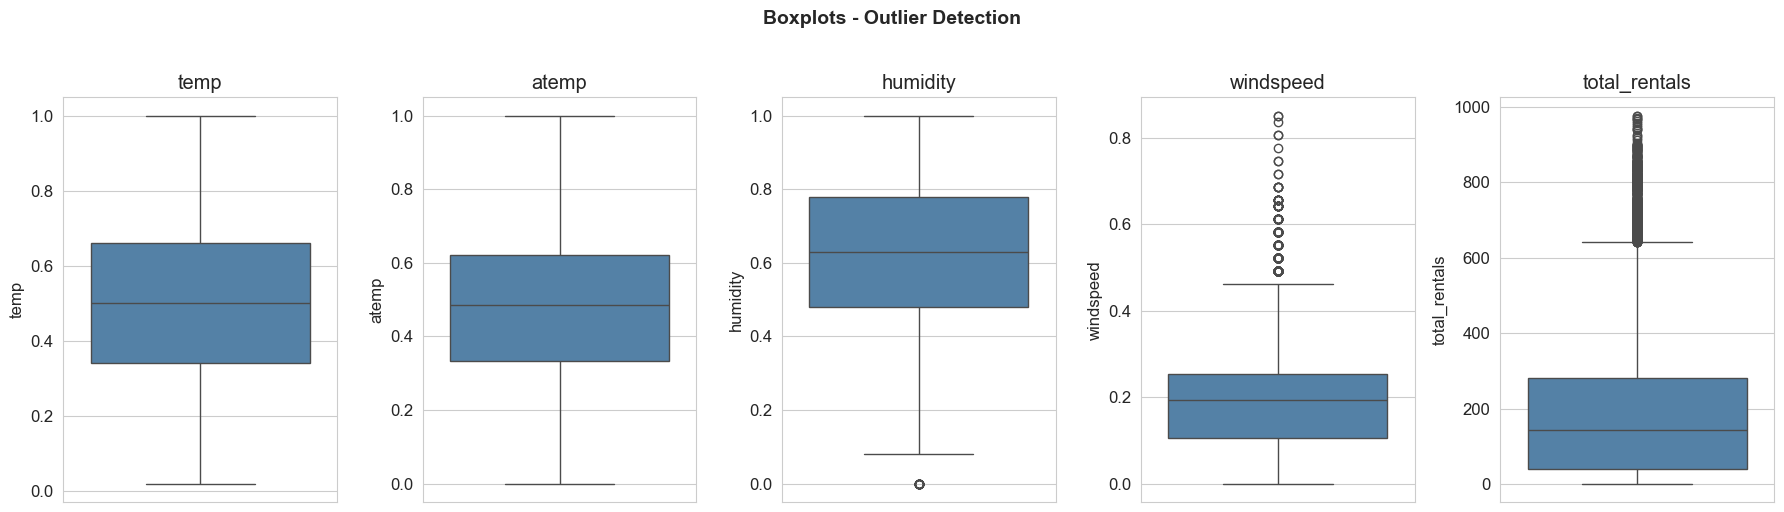

In [47]:
outlier_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'total_rentals']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots - Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

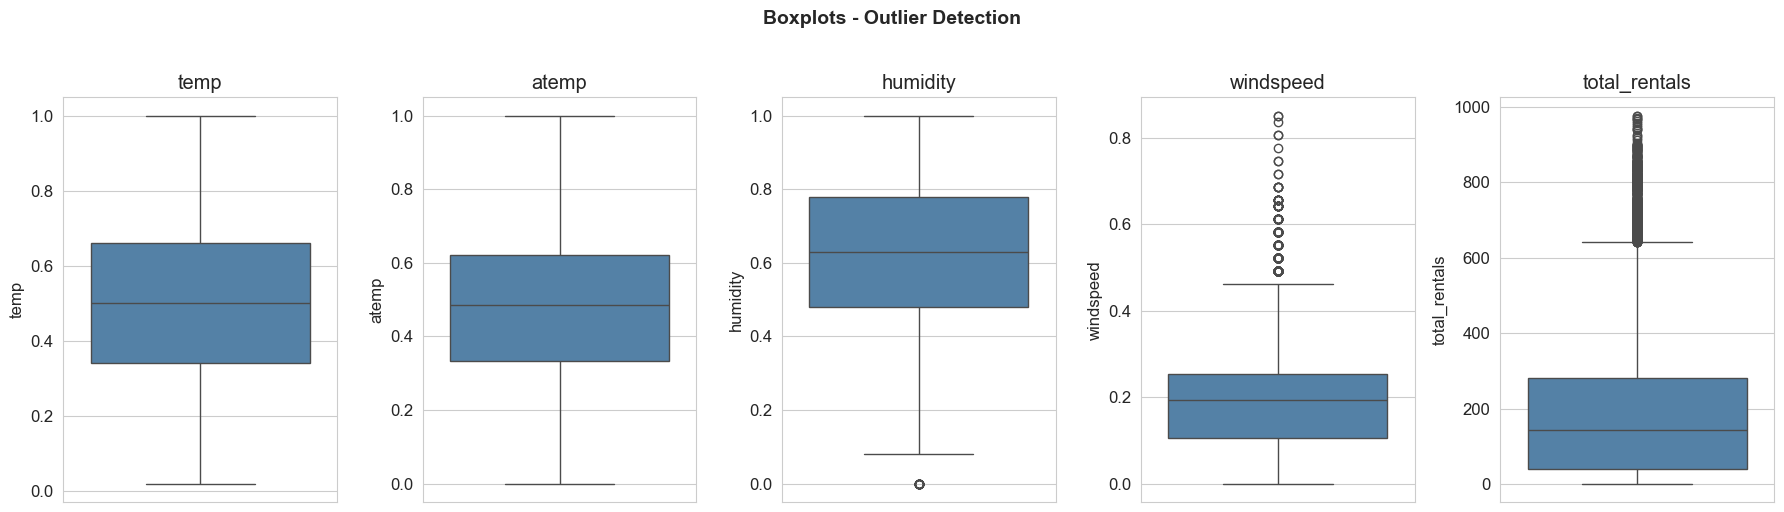

In [48]:
outlier_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'total_rentals']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots - Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4c. Categorical Variable Refinement
Standardizing labels and grouping low-frequency categories to improve consistency.

In [49]:
df['season'] = df['season'].replace({'springer': 'spring'})
df['weathersit'] = df['weathersit'].replace({'heavy rain': 'light snow'})

print("Season values:")
print(sorted(df['season'].dropna().unique()))

print("\nWeatherSit values:")
print(sorted(df['weathersit'].dropna().unique()))

Season values:
['fall', 'spring', 'summer', 'winter']

WeatherSit values:
['Clear', 'Heavy Rain', 'Light Snow', 'Mist']


## 📈 Step 5: Univariate & Multivariate Analysis
Exploring distributions and relationships between features and the target variable (`total_rentals`).

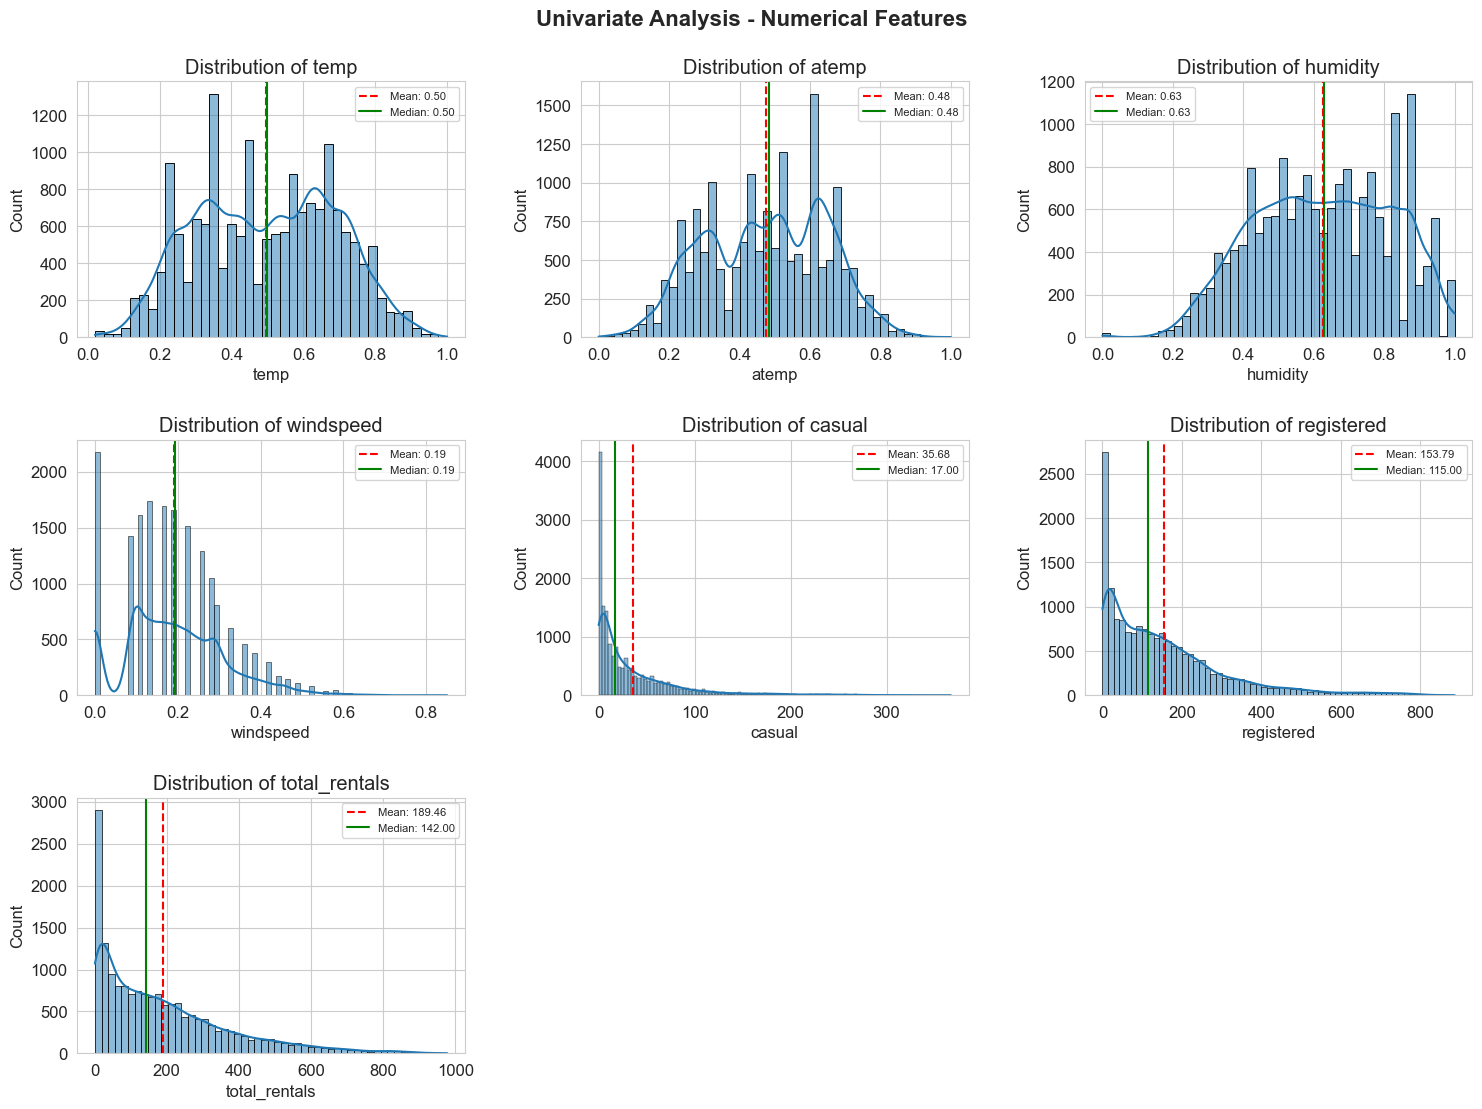

In [50]:
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'total_rentals']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    mean_val = df[col].mean()
    median_val = df[col].median()

    sns.histplot(df[col], kde=True, ax=axes[i], edgecolor='black')

    # Mean → RED
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')

    # Median → GREEN
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(fontsize=8)

# Remove extra plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)

plt.suptitle('Univariate Analysis - Numerical Features', fontsize=16, fontweight='bold')
plt.show()

**Key findings:** `temp` and `atemp` are roughly symmetric (well-balanced distributions). `humidity` and `windspeed` show mild right skew. `casual`, `registered`, and `total_rentals` are strongly right-skewed — most values are low to moderate with a long tail of high-demand days. `casual` is the most skewed (median much lower than mean). Rental-related features show clear demand variability with occasional spikes.


### Time-Based Breakdown

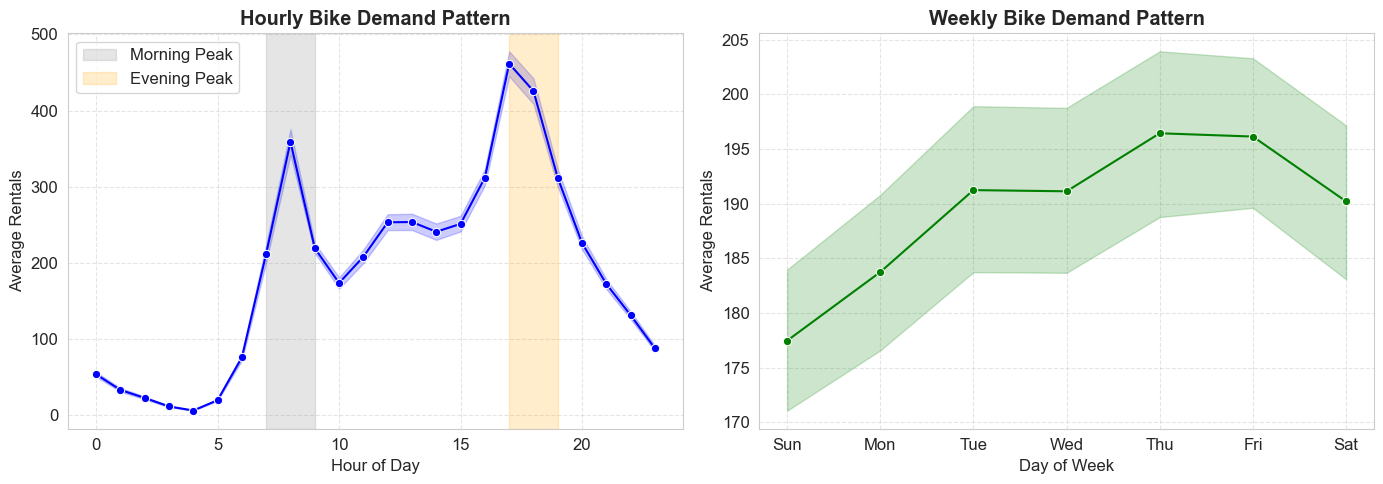

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Hourly Demand
sns.lineplot(
    x='hour', y='total_rentals', data=df,
    ax=axes[0],
    marker='o',
    color='blue'
)
axes[0].set_title('Hourly Bike Demand Pattern', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Rentals')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Highlight peak hours (example: commute times)
axes[0].axvspan(7, 9, color='gray', alpha=0.2, label='Morning Peak')
axes[0].axvspan(17, 19, color='orange', alpha=0.2, label='Evening Peak')
axes[0].legend()

# Weekly Demand
sns.lineplot(
    x='weekday', y='total_rentals', data=df,
    ax=axes[1],
    marker='o',
    color='green'
)
axes[1].set_title('Weekly Bike Demand Pattern', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Rentals')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Optional: Label weekdays
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])

plt.tight_layout()
plt.show()

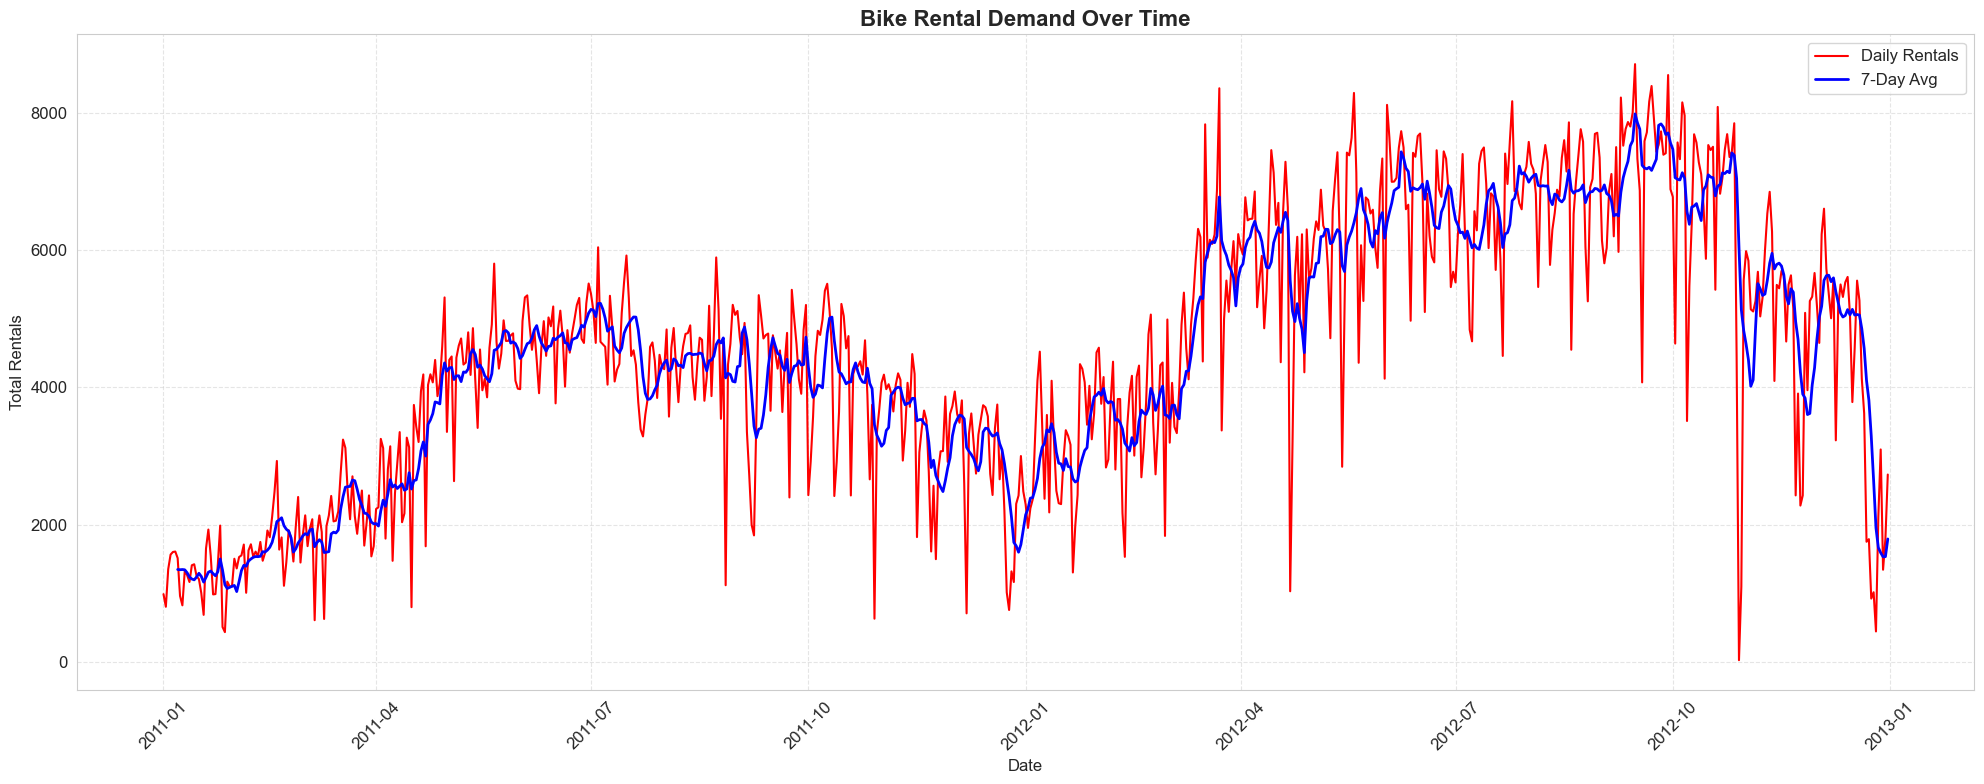

In [52]:
# Aggregate to daily demand
daily_df = df.groupby('date')['total_rentals'].sum().reset_index()

plt.figure(figsize=(20, 8))

# Actual demand
sns.lineplot(
    x='date',
    y='total_rentals',
    data=daily_df,
    color='red',
    linewidth=1.5,
    label='Daily Rentals'
)

# 7-day rolling average (trend)
daily_df['rolling_avg'] = daily_df['total_rentals'].rolling(window=7).mean()

sns.lineplot(
    x='date',
    y='rolling_avg',
    data=daily_df,
    color='blue',
    linewidth=2,
    label='7-Day Avg'
)

# Labels & styling
plt.title("Bike Rental Demand Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total Rentals")

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

## Step 6: Summary Dashboard & Key Insights

This section provides a consolidated view of the most critical findings from our Exploratory Data Analysis.

### 📊 Key Insights Observed:
1.  **Peak Demand Hours**: Clear spikes during morning (7 AM - 9 AM) and evening (5 PM - 7 PM) rush hours, indicating strong utility for commuting.
2.  **Seasonal Trends**: Demand is significantly higher in **Fall and Summer** compared to Spring and Winter, likely due to more favorable weather conditions.
3.  **Weekday vs Weekend**: Demand is consistent throughout the workweek, while weekend patterns show a more gradual rise in the afternoon (leisure usage).
4.  **Weather Impact**: Clear/Misty weather is strongly preferred; demand drops drastically during periods of light snow or heavy rain.

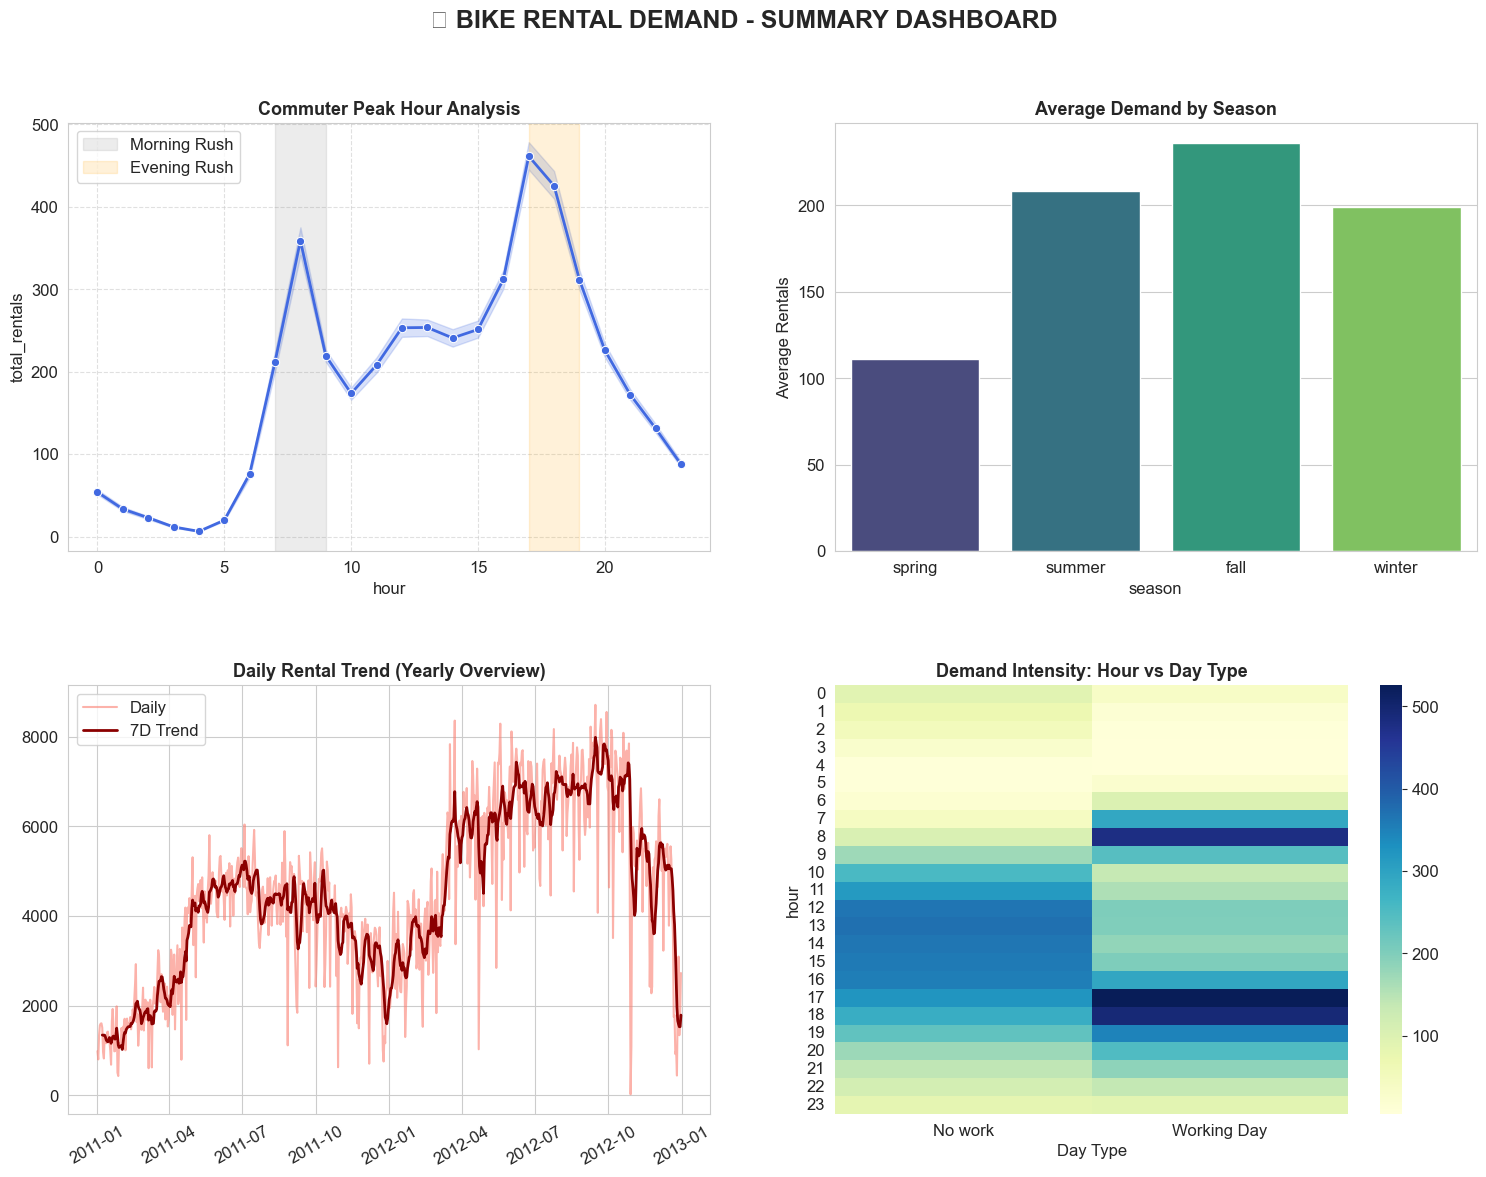

In [53]:
# Final Summary Dashboard
plt.figure(figsize=(16, 12))

# 1. Hourly Pattern (Commuter Insights)
plt.subplot(2, 2, 1)
sns.lineplot(x='hour', y='total_rentals', data=df, marker='o', color='royalblue', linewidth=2)
plt.axvspan(7, 9, color='gray', alpha=0.15, label='Morning Rush')
plt.axvspan(17, 19, color='orange', alpha=0.15, label='Evening Rush')
plt.title('Commuter Peak Hour Analysis', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Seasonal Demand Distribution
plt.subplot(2, 2, 2)
sns.barplot(x='season', y='total_rentals', data=df, palette='viridis', ci=None)
plt.title('Average Demand by Season', fontsize=13, fontweight='bold')
plt.ylabel('Average Rentals')

# 3. Monthly Trend (Daily Aggregated)
plt.subplot(2, 2, 3)
daily_counts = df.groupby('date')['total_rentals'].sum().reset_index()
plt.plot(daily_counts['date'], daily_counts['total_rentals'], color='salmon', alpha=0.6, label='Daily')
plt.plot(daily_counts['date'], daily_counts['total_rentals'].rolling(7).mean(), color='darkred', linewidth=2, label='7D Trend')
plt.title('Daily Rental Trend (Yearly Overview)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.legend()

# 4. Heatmap: Hour vs Day Type (Weekend vs Workday)
plt.subplot(2, 2, 4)
pivot_table = df.pivot_table(values='total_rentals', index='hour', columns='workingday', aggfunc='mean')
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title('Demand Intensity: Hour vs Day Type', fontsize=13, fontweight='bold')
plt.xlabel('Day Type')

plt.tight_layout(pad=4.0)
plt.suptitle('🚲 BIKE RENTAL DEMAND - SUMMARY DASHBOARD', fontsize=18, fontweight='bold', y=1.02)
plt.show()

# Exporting the dashboard for the README
plt.savefig('summary_dashboard.png', bbox_inches='tight', dpi=300)
